In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("../data/molecules.csv")

# Show first rows
df.head()

,Unnamed: 0,ChEMBL ID,Name,SMILES,Molecular Weight,LogP,HBA,HBD,TPSA,Protein
0,0,CHEMBL292323,NaN,COc1cccc2c(C(=O)Nc3ccccc3)c(SSc3c(C(=O)Nc4cccc...,622.77,7.99,8.0,2.0,86.52,EGFR
1,1,CHEMBL304414,NaN,Cn1c(SSc2c(C(=O)Nc3ccccc3)c3ccccc3n2C)c(C(=O)N...,562.72,7.97,6.0,2.0,68.06,EGFR
2,2,CHEMBL62176,NaN,CN1C(=S)C(C(=O)Nc2ccccc2)c2ccccc21,282.37,3.19,2.0,1.0,32.34,EGFR
3,3,CHEMBL62701,NaN,Cn1c(SSc2c(C(=O)Nc3ccccc3)c3cccnc3n2C)c(C(=O)N...,564.70,6.76,8.0,2.0,93.84,EGFR
4,4,CHEMBL137617,NaN,C/N=N/Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,357.22,4.54,5.0,2.0,74.56,EGFR


In [2]:
# Check columns and data types
df.info()

# Basic statistics
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1422 entries, 0 to 1421
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1422 non-null   int64  
 1   ChEMBL ID         1422 non-null   object 
 2   Name              140 non-null    object 
 3   SMILES            1420 non-null   object 
 4   Molecular Weight  1420 non-null   float64
 5   LogP              1412 non-null   float64
 6   HBA               1412 non-null   float64
 7   HBD               1412 non-null   float64
 8   TPSA              1412 non-null   float64
 9   Protein           1422 non-null   object 
dtypes: float64(5), int64(1), object(4)
memory usage: 111.2+ KB


,Unnamed: 0,Molecular Weight,LogP,HBA,HBD,TPSA
count,1422.000000,1420.000000,1412.000000,1412.000000,1412.000000,1412.000000
mean,710.500000,411.890831,3.705092,4.843484,1.223088,58.335574
std,410.640354,114.550740,1.396605,1.663893,1.284683,26.688567
min,0.000000,135.170000,-0.290000,1.000000,0.000000,3.240000
25%,355.250000,345.997500,2.870000,4.000000,0.000000,41.370000
50%,710.500000,399.510000,3.580000,5.000000,1.000000,54.040000
75%,1065.750000,449.590000,4.302500,6.000000,2.000000,72.160000
max,1421.000000,1658.950000,13.320000,16.000000,7.000000,208.750000


In [3]:
# Remove unnecessary column
df = df.drop(columns=["Unnamed: 0"], errors='ignore')

# Drop missing values
df = df.dropna()

# Keep valid SMILES only
df = df[df["SMILES"].notnull()]

print("Shape after cleaning:", df.shape)

Shape after cleaning: (139, 9)


In [4]:
from rdkit import Chem

# Convert SMILES → molecule
df["mol"] = df["SMILES"].apply(lambda x: Chem.MolFromSmiles(x))

# Remove invalid molecules
df = df[df["mol"].notnull()]

print("After RDKit conversion:", df.shape)

After RDKit conversion: (139, 10)


In [6]:
from rdkit.Chem import Descriptors

df["MolWt_rdkit"] = df["mol"].apply(lambda m: Descriptors.MolWt(m))

In [7]:
def lipinski(row):
    if (row["Molecular Weight"] < 500 and
        row["LogP"] < 5 and
        row["HBA"] <= 10 and
        row["HBD"] <= 5):
        return 1
    else:
        return 0

df["drug_like"] = df.apply(lipinski, axis=1)

df["drug_like"].value_counts()

drug_like
1    111
0     28
Name: count, dtype: int64

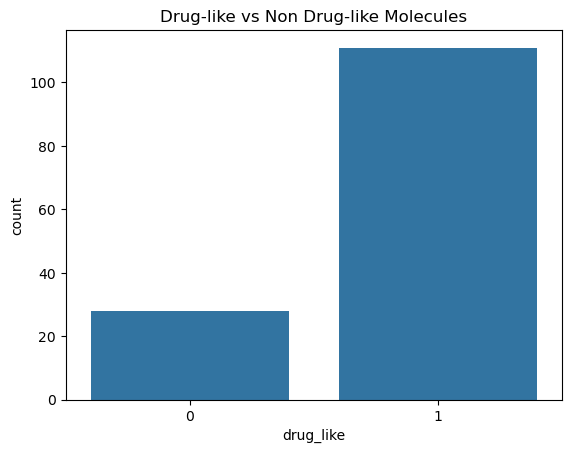

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="drug_like", data=df)
plt.title("Drug-like vs Non Drug-like Molecules")
plt.show()

In [9]:
from sklearn.cluster import KMeans

X = df[["Molecular Weight", "LogP", "TPSA"]]

kmeans = KMeans(n_clusters=3, random_state=42)
df["cluster"] = kmeans.fit_predict(X)

C:\Users\Mimanasa\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


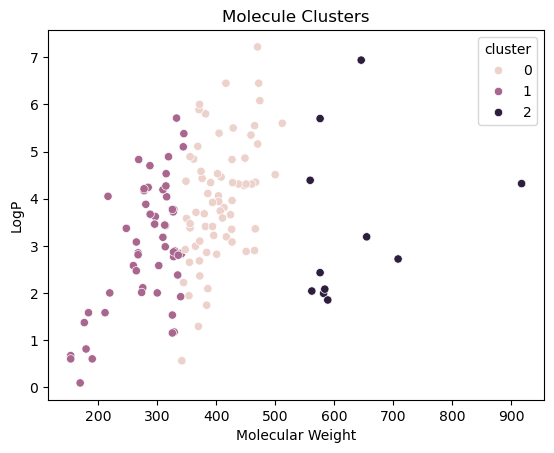

In [10]:
sns.scatterplot(x="Molecular Weight", y="LogP", hue="cluster", data=df)
plt.title("Molecule Clusters")
plt.show()

In [13]:
df["activity"] = df["LogP"] * df["drug_like"]

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X = df[["Molecular Weight", "LogP", "HBA", "HBD", "TPSA"]]
y = df["activity"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

model = RandomForestRegressor()
model.fit(X_train, y_train)

df["predicted_activity"] = model.predict(X)

In [15]:
df = df.sort_values("predicted_activity", ascending=False)

df[["ChEMBL ID", "SMILES", "predicted_activity"]].head(10)

,ChEMBL ID,SMILES,predicted_activity
739,CHEMBL1112,O=C1CCc2ccc(OCCCCN3CCN(c4cccc(Cl)c4Cl)CC3)cc2N1,4.8430
1215,CHEMBL1713,CN(C)CCCN1c2ccccc2Sc2ccc(Cl)cc21.Cl,4.8428
819,CHEMBL8514,CC(C)(C)[C@]1(O)CCN2C[C@H]3c4ccccc4CCc4cccc(c4...,4.8393
610,CHEMBL71,CN(C)CCCN1c2ccccc2Sc2ccc(Cl)cc21,4.8352
608,CHEMBL411,CC/C(=C(/CC)c1ccc(O)cc1)c1ccc(O)cc1,4.8199
177,CHEMBL14376,COc1cc(C(C)=O)ccc1OCCCN1CCC(c2noc3cc(F)ccc23)CC1,4.8149
612,CHEMBL516,CN1CCC(=C2c3ccccc3C=Cc3ccccc32)CC1,4.6789
621,CHEMBL728,CN1CCN(CCCN2c3ccccc3Sc3ccc(Cl)cc32)CC1,4.5435
611,CHEMBL415,CN(C)CCCN1c2ccccc2CCc2ccc(Cl)cc21,4.5283
618,CHEMBL1909072,NC(=O)C1CCN(CCCN2c3ccccc3Sc3ccc(Cl)cc32)CC1,4.5255


In [16]:
from rdkit.Chem import AllChem
from rdkit import DataStructs

# Generate fingerprints
df["fingerprint"] = df["mol"].apply(lambda m: AllChem.GetMorganFingerprintAsBitVect(m, 2))

# Compare first molecule with others
ref_fp = df["fingerprint"].iloc[0]

similarities = []

for fp in df["fingerprint"]:
    sim = DataStructs.TanimotoSimilarity(ref_fp, fp)
    similarities.append(sim)

df["similarity_to_ref"] = similarities

df[["ChEMBL ID", "similarity_to_ref"]].head()

,ChEMBL ID,similarity_to_ref
739,CHEMBL1112,1.000000
1215,CHEMBL1713,0.162500
819,CHEMBL8514,0.137931
610,CHEMBL71,0.164557
608,CHEMBL411,0.058824


In [17]:
df_sorted = df.sort_values("similarity_to_ref", ascending=False)

df_sorted[["ChEMBL ID", "similarity_to_ref"]].head(10)

,ChEMBL ID,similarity_to_ref
739,CHEMBL1112,1.000000
1306,CHEMBL5095172,0.718750
774,CHEMBL2028019,0.350649
259,CHEMBL708,0.329268
1101,CHEMBL621,0.278481
586,CHEMBL49,0.270270
621,CHEMBL728,0.266667
738,CHEMBL218166,0.253165
748,CHEMBL567,0.246753
611,CHEMBL415,0.243243


In [18]:
df.to_csv("../results/top_molecules.csv", index=False)

print("✅ Project output saved!")

✅ Project output saved!


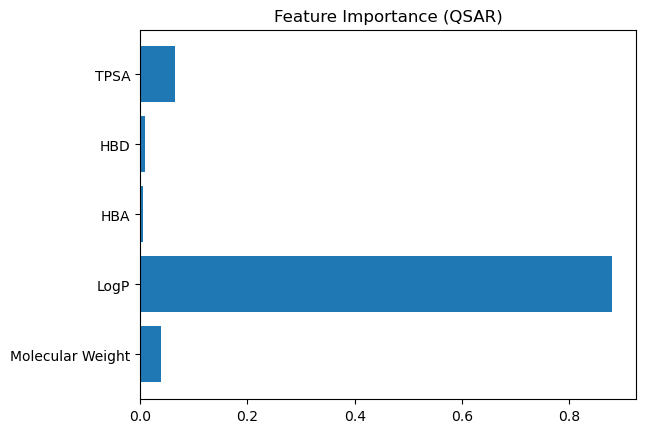

In [19]:
import matplotlib.pyplot as plt

importance = model.feature_importances_
features = X.columns

plt.barh(features, importance)
plt.title("Feature Importance (QSAR)")
plt.show()